<Figure size 1200x600 with 0 Axes>

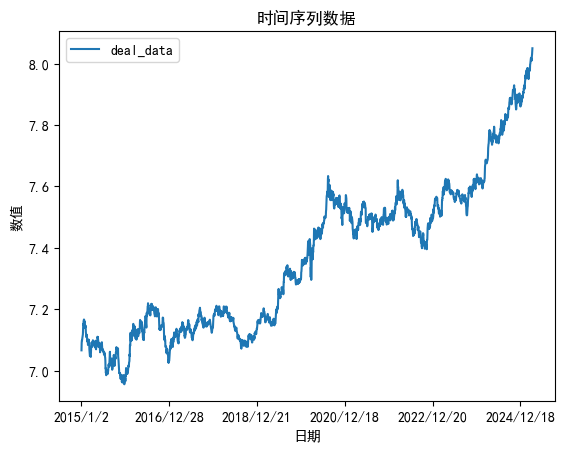

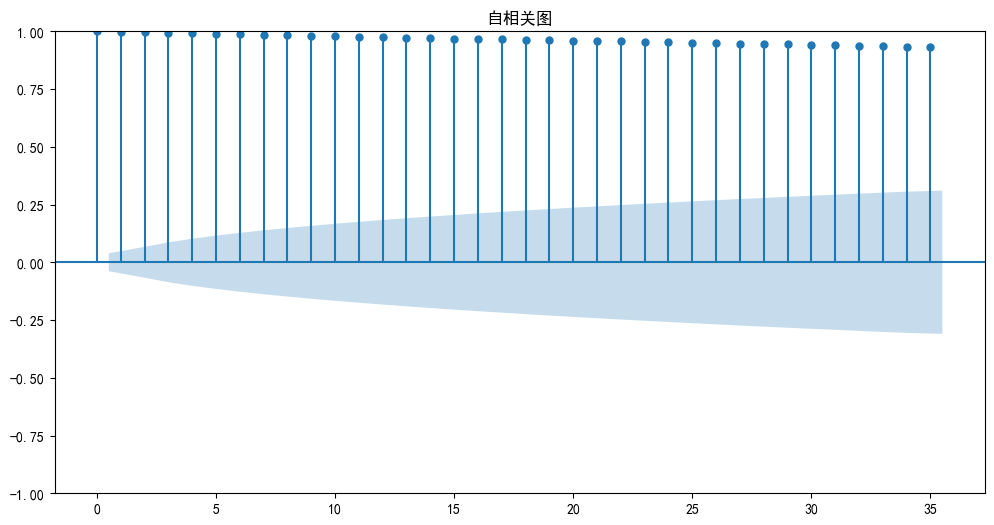

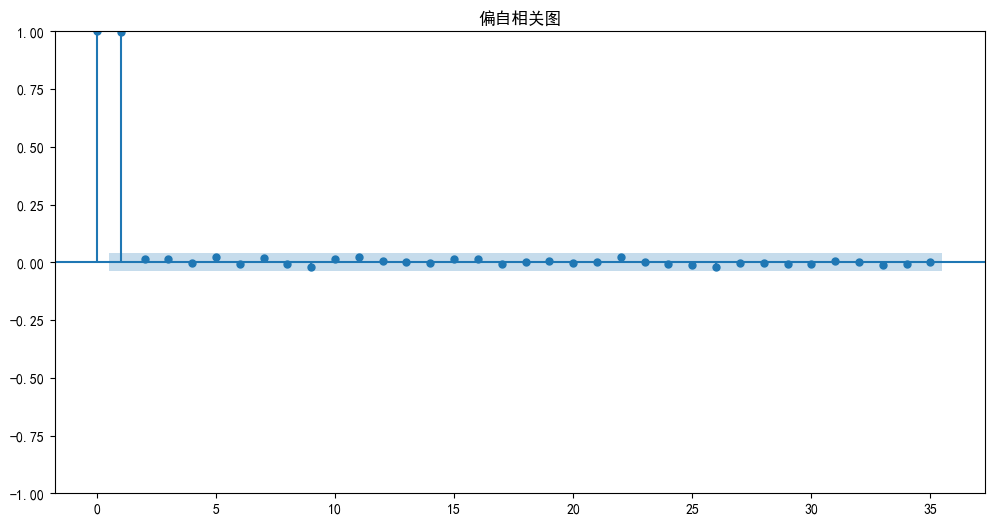

对数处理原始序列后，ADF检验结果为： (1.218129095119431, 0.996108775580083, 22, 2547, {'1%': -3.432920044265089, '5%': -2.86267544111504, '10%': -2.5673744377173606}, -16800.63732163096)


In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller as ADF
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #ACF与PACF
from statsmodels.tsa.arima.model import ARIMA #ARIMA模型
from scipy import stats

df=pd.read_csv('../data/huangjin_test.csv', encoding= 'GB2312')

# 设置索引
df.set_index(['time_data'], inplace=True)
data = df

# 对原始数据取对数
ts_data_log = np.log(data)

# 绘制时序图
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
# 绘制时序图
plt.figure(figsize=(12, 6))  # 设置图片大小为 12x6
#df['deal_data'].plot()
ts_data_log.plot()
plt.title('时间序列数据')
plt.xlabel('日期')
plt.ylabel('数值')
plt.show()

# 绘制自相关图
fig, ax = plt.subplots(figsize=(12, 6))
#plot_acf(df['deal_data'], ax=ax)
plot_acf(ts_data_log, ax=ax)
plt.title('自相关图')
plt.show()

# 绘制偏自相关图
fig, ax = plt.subplots(figsize=(12, 6))
#plot_pacf(df['deal_data'], ax=ax)
plot_pacf(ts_data_log, ax=ax)
plt.title('偏自相关图')
plt.show()

# 平稳性检测
#print(u'原始序列的ADF检验结果为：', ADF(df['deal_data']))
print(u'对数处理原始序列后，ADF检验结果为：', ADF(ts_data_log))


# 根据平稳性检验结果 能得出数据明显不稳定

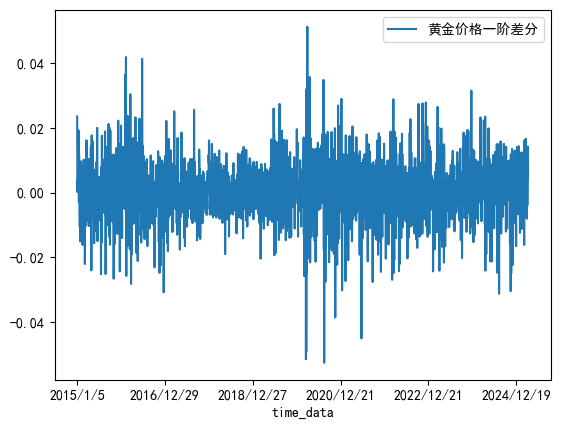

<Figure size 1000x600 with 0 Axes>

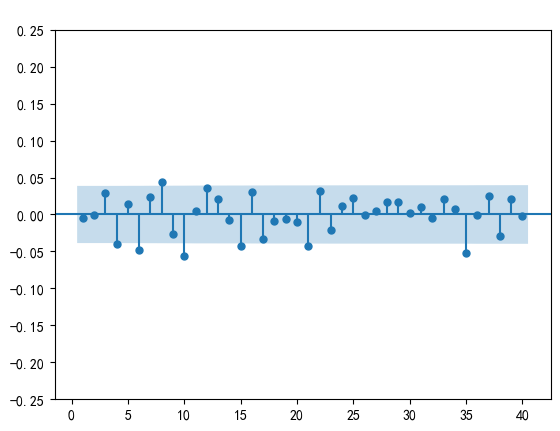

<Figure size 1000x600 with 0 Axes>

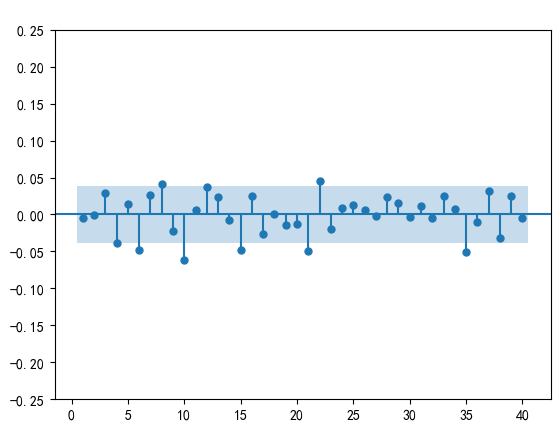

一阶差分序列的ADF检验结果为： (-11.260579248919383, 1.6258777397491574e-20, 21, 2547, {'1%': -3.432920044265089, '5%': -2.86267544111504, '10%': -2.5673744377173606}, -16793.767499757)


In [2]:
import warnings
warnings.filterwarnings("ignore")

D_data = ts_data_log.diff().dropna()  #一阶差分并去空列
D_data.columns = [u'黄金价格一阶差分']
# 时序图
D_data.plot()
plt.show()

# 绘制自相关图（去除零阶）
plt.figure(figsize=(10, 6))
plot_acf(D_data, lags=40, zero=False)
plt.title(u' ')
plt.ylim(-0.25, 0.25) 
plt.yticks(np.arange(-0.25, 0.26, 0.05))
plt.show()

# 绘制偏自相关图（去除零阶）
plt.figure(figsize=(10, 6))
plot_pacf(D_data, lags=40, zero=False) 
plt.title(u' ')
plt.ylim(-0.25, 0.25) 
plt.yticks(np.arange(-0.25, 0.26, 0.05))
plt.show()

print(u'一阶差分序列的ADF检验结果为：', ADF(D_data[u'黄金价格一阶差分']))  # 平稳性检测

#p值接近0  说明处理后数据稳定


In [3]:

print(u'差分序列的白噪声检验结果为：', acorr_ljungbox(D_data, lags=1))  # 返回统计量和p值       通过数据结果，说明不是白噪声


差分序列的白噪声检验结果为：     lb_stat  lb_pvalue
1  0.055979   0.812968


In [4]:
AIC = sm.tsa.stattools.arma_order_select_ic(D_data, max_ar=4, max_ma=4, ic='aic')['aic_min_order']
BIC = sm.tsa.stattools.arma_order_select_ic(D_data, max_ar=4, max_ma=4, ic='bic')['bic_min_order']

print('---AIC与BIC准则定阶---')
print('the AIC is{}\nthe BIC is{}\n'.format(AIC, BIC), end='')
p = BIC[0]
q = BIC[1]
diff_num = 1

#以上为自动定阶
#如果人工的话 可能8 1 8

---AIC与BIC准则定阶---
the AIC is(0, 0)
the BIC is(0, 0)


In [4]:
model = ARIMA(ts_data_log, order=(12, 1, 12)).fit()  # 建立ARIMA(p, diff+num, q)模型

r_squared = 1 - (model.resid.var() / data.var())
print(f"R-squared: {r_squared}")

#不管怎么样 R²都是1

R-squared: deal_data    1.0
dtype: float64


     lb_stat  lb_pvalue
1   0.027727   0.867753
2   0.031189   0.984527
3   0.031189   0.998549
4   0.031764   0.999875
5   0.032014   0.999990
6   0.034641   0.999999
7   0.035819   1.000000
8   0.036050   1.000000
9   0.051580   1.000000
10  0.062417   1.000000
11  0.062695   1.000000
12  0.069155   1.000000
13  0.069711   1.000000
14  0.069725   1.000000
15  0.069817   1.000000
16  0.074071   1.000000
17  0.074463   1.000000
18  0.074479   1.000000
19  0.085282   1.000000
20  0.088927   1.000000


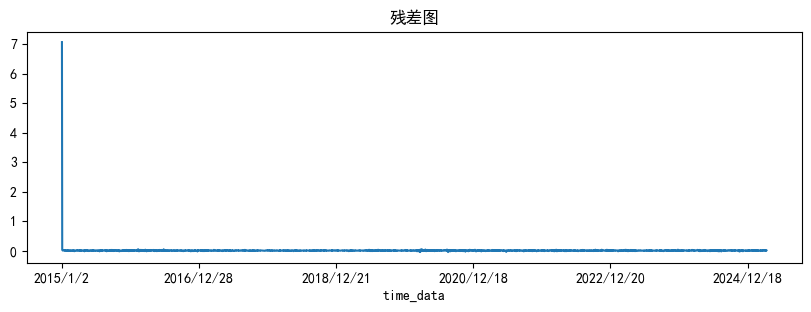

------------残差检验-----------
NormaltestResult(statistic=8198.642921534993, pvalue=0.0)


In [5]:
model = ARIMA(ts_data_log, order=(12, 1, 12)).fit() 

from statsmodels.stats.diagnostic import acorr_ljungbox as lb_test
re = lb_test(model.resid, lags=20)
print(re)

#模型检验
def Model_checking(model):
    # 残差检验:检验残差是否服从正态分布，画图查看，然后检验
    # 绘制残差图
    model.resid.plot(figsize=(10, 3))
    plt.title("残差图")
    plt.show()

    print('------------残差检验-----------')
    # model.resid：残差 = 实际观测值 – 模型预测值
    print(stats.normaltest(model.resid))
    

Model_checking(model)